# Replica of the scITD Analysis

The goal of this ntoebook is to replicate, on the breast-cancer data which is provided, the analysis which scITD conducts in order to gain insight on how tensor decompositions can be used to meaningfully analyse cell-cycle data.

## 0. Imports:

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly import tenalg

---

## 1. Data import:

In [8]:
from pathlib import Path

data_dir = Path("../data/breast_cancer_zikry_wayne")
h5ad_files = sorted(data_dir.glob("*.h5ad"))
if not h5ad_files:
    raise FileNotFoundError(f"No .h5ad files found in {data_dir}")

adatas = [sc.read_h5ad(str(p)) for p in h5ad_files]

adata = sc.concat(
    adatas,
    join="outer",
    label="source_file",
    keys=[p.stem for p in h5ad_files],
    index_unique="-",
)

We subset to the following features:

In [11]:
features_44PE = [
    'nuclear_mean_pH2AX','nuclear_mean_53BP1', 'nuclear_mean_ECad', 
    'nuclear_mean_HER2', 'nuclear_mean_cycD1', 'nuclear_mean_CDK4',
    'nuclear_mean_cycE1', 'nuclear_mean_HES1', 'nuclear_mean_pRB',
    'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 
    'DNA_int', 'nuclear_mean_CycB1'
]

features_134 = [
    'nuclear_mean_CDK4', 'nuclear_mean_cycE1', 'nuclear_mean_pH2AX', 
    'nuclear_mean_53BP1','nuclear_mean_p16', 'nuclear_mean_pRB',
    'nuclear_mean_PH3','nuclear_mean_cycA2','nuclear_mean_Plk1','DNA_int'
]

features_231 = [
    'nuclear_mean_cycD1', 'nuclear_mean_CDK4', 'nuclear_mean_pH2AX', 
    'nuclear_mean_ERa', 'nuclear_mean_pRB', 'nuclear_mean_PH3',
    'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 'DNA_int'
]

features_453 = [
    'nuclear_mean_pH2AX', 'nuclear_mean_pAKT', 'nuclear_mean_CDK4',
    'nuclear_mean_RB', 'nuclear_mean_CDK2', 'nuclear_mean_CycB1',
    'nuclear_mean_cycD1', 'nuclear_mean_cycE1', 'nuclear_mean_CDC25c', 
    'nuclear_mean_pRB', 'nuclear_mean_PH3', 'nuclear_mean_cycA2',
    'nuclear_mean_Plk1', 'DNA_int'
]

features_BCK4 = [
    'nuclear_mean_HES1', 'nuclear_mean_pH2AX', 'nuclear_mean_bCat',
    'nuclear_mean_ERa', 'nuclear_mean_DAPI', 'nuclear_mean_CDK4',
    'nuclear_mean_pRB', 'nuclear_mean_PH3', 'nuclear_mean_cycA2',
    'nuclear_mean_Plk1', 'DNA_int'
]

features_MCF7 = [
    'nuclear_mean_HER2', 'nuclear_mean_cycE1', 'cyto_mean_CDC25c',
    'cyto_mean_PR', 'cyto_mean_p21', 'nuclear_mean_CDC25c',
    'nuclear_mean_cycA1', 'nuclear_mean_pRB', 'nuclear_mean_PH3',
    'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 'DNA_int'
]

features_T47D = [
    'nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX', 
    'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
    'nuclear_mean_CDK2', 'nuclear_mean_cycE1', 'nuclear_mean_pRB',
    'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
    'DNA_int'
]

features_MCF10A = [
    'nuclear_mean_ERa', 'nuclear_mean_pRB', 'pRB/RB', 
    'nuclear_mean_HES1', 'nuclear_mean_Ki67', 'nuclear_mean_cycB2',
    'nuclear_mean_cycD1', 'nuclear_mean_RB', 'nuclear_mean_pRB',
    'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
    'DNA_int'
]


In [12]:
selected_features = list(
    set(features_44PE) 
    & set(features_134)
    & set(features_231)
    & set(features_453)
    & set(features_BCK4)
    & set(features_MCF7)
    & set(features_T47D)
    & set(features_MCF10A)
)

adata = adata[:, selected_features]

Understanding our data:

In [13]:
print(f'n_obs x n_vars: {adata.shape}')

n_obs x n_vars: (2121333, 5)


In [14]:
print(f'cell barcodes (row index): {adata.obs_names}\n')
print(f'gene/feature names (column index): {adata.var_names}\n')

cell barcodes (row index): Index(['0-134_merged', '1-134_merged', '2-134_merged', '3-134_merged',
       '4-134_merged', '5-134_merged', '6-134_merged', '7-134_merged',
       '8-134_merged', '9-134_merged',
       ...
       '144088-T47D_merged', '144089-T47D_merged', '144090-T47D_merged',
       '144091-T47D_merged', '144092-T47D_merged', '144093-T47D_merged',
       '144094-T47D_merged', '144095-T47D_merged', '144096-T47D_merged',
       '144097-T47D_merged'],
      dtype='object', length=2121333)

gene/feature names (column index): Index(['nuclear_mean_pRB', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
       'DNA_int', 'nuclear_mean_PH3'],
      dtype='object')



In [15]:
adata.obs

,core,binucleated,CellID,GMM_phase_labels,DNA_int_obs,nuclear_mean_cycA2_obs,Endocycle,drug_name,source_file
0-134_merged,1.0,0,0,G1,2.852778,174.067138,Diploid,Control,134_merged
1-134_merged,1.0,0,1,G2,4.277782,7286.788861,Diploid,Control,134_merged
2-134_merged,1.0,0,2,M,3.825389,4637.076161,Diploid,Control,134_merged
3-134_merged,1.0,0,3,G1,2.058231,91.620798,Diploid,Control,134_merged
4-134_merged,1.0,0,4,S,2.739487,2175.699147,Diploid,Control,134_merged
...,...,...,...,...,...,...,...,...,...
144093-T47D_merged,8.0,0,144093,G1,2.205912,240.395580,Diploid,Dinaciclib,T47D_merged
144094-T47D_merged,8.0,0,144094,G1,2.033355,193.921158,Diploid,Dinaciclib,T47D_merged
144095-T47D_merged,8.0,0,144095,G0,2.081168,531.183796,Diploid,Dinaciclib,T47D_merged
144096-T47D_merged,8.0,0,144096,G0,1.971715,174.206118,Diploid,Dinaciclib,T47D_merged


In [16]:
total = adata.obs['drug_name'].value_counts().sum()
adata.obs['drug_name'].value_counts() / total

drug_name
RO-3306         0.301241
Palbociclib     0.140028
Control         0.125868
CVT-313         0.121824
Dinaciclib      0.106363
Talazoparib     0.077380
PF-3600         0.064703
Samuraciclib    0.062594
Name: count, dtype: float64

In [17]:
pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

,nuclear_mean_pRB,nuclear_mean_cycA2,nuclear_mean_Plk1,DNA_int,nuclear_mean_PH3
0-134_merged,2598.838634,174.067138,183.088339,2.852778,772.422850
1-134_merged,3093.479634,7286.788861,498.014963,4.277782,1836.716542
2-134_merged,3020.639756,4637.076161,311.682407,3.825389,11301.259711
3-134_merged,2442.421218,91.620798,187.529412,2.058231,619.453782
4-134_merged,3132.432400,2175.699147,226.690621,2.739487,1055.071864
...,...,...,...,...,...
144093-T47D_merged,1109.131492,240.395580,182.297238,2.205912,589.051934
144094-T47D_merged,578.515968,193.921158,507.659681,2.033355,1085.689621
144095-T47D_merged,384.794449,531.183796,223.363091,2.081168,385.189047
144096-T47D_merged,173.493176,174.206118,161.687529,1.971715,359.054118


In [18]:
condition_G0_M = (~adata.obs['GMM_phase_labels'].isin(['G0', 'M']))
adata_sans_G0_M = adata[condition_G0_M]

Calculating PHATE...
  Running PHATE on 10000 observations and 5 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.07 seconds.
    Calculating affinities...
    Calculated affinities in 0.10 seconds.
  Calculated graph and diffusion operator in 0.18 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.23 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.30 seconds.
  Calculated landmark operator in 1.53 seconds.
  Calculating optimal t...
    Automatically selected t = 23
  Calculated optimal t in 0.99 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.31 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.18 seconds.
Calculated PHATE in 4.49 seconds.


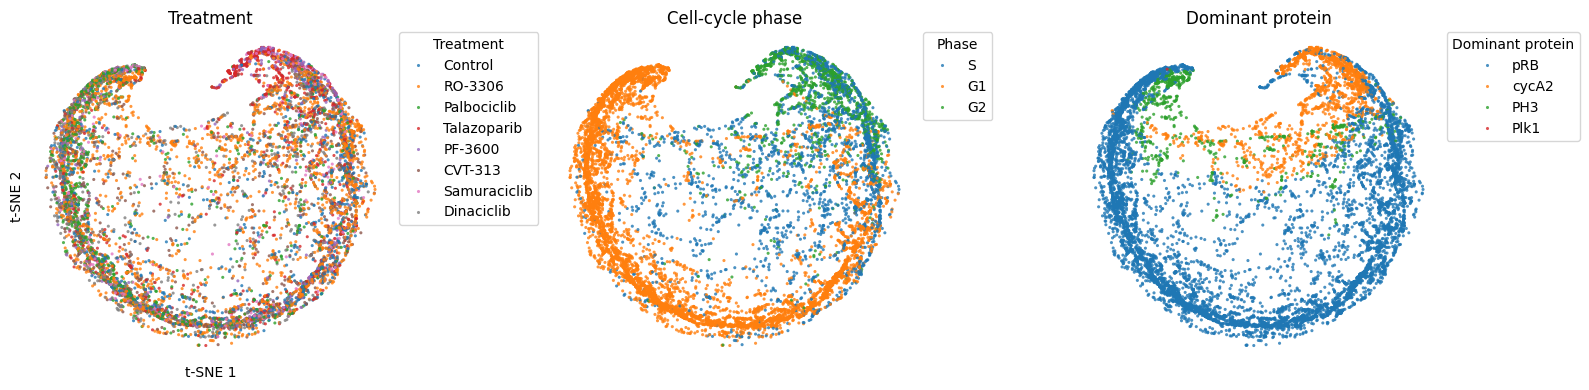

In [20]:
import phate

dot_size = 5

# PHATE on sampled data
adata_sub = sc.pp.subsample(adata_sans_G0_M, n_obs=min(10000, adata_sans_G0_M.n_obs), copy=True, random_state=0)
phate_op = phate.PHATE()
data_phate = phate_op.fit_transform(adata_sub.X)
dominant_protein = adata_sub[:, selected_features].to_df().idxmax(axis=1)

phate = pd.DataFrame(
    data_phate, 
    columns=["PHATE 1", "PHATE 2"],
    index=adata_sub.obs_names,
)

phate["treatment"] = adata_sub.obs["drug_name"].astype(str).values
phate["phase"] = adata_sub.obs["GMM_phase_labels"].astype(str).values
phate["protein"] = np.asarray(adata_sub[:, "DNA_int"].X).ravel()
phate["dominant_protein"] = dominant_protein.str.removeprefix("nuclear_mean_").values


# Set up visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.despine(top=True, right=True, left=True, bottom=True)


# Treatment
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="treatment",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Treatment")
axes[0].legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Cell-cycle phase
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="phase",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Cell-cycle phase")
axes[1].legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Dominant protein per sample
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="dominant_protein",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[2], palette="tab10"
)
axes[2].set_title("Dominant protein")
axes[2].legend(
    title="Dominant protein", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)


# Final touches
for ax in axes:
    if ax == axes[0]: 
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
    else: 
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

---

## 2. Data analysis:

Our idea is to, model our tensor via: $\textit{treatment} \times \textit{cell-cycle phase} \times \textit{protein} \times \textit{sample}$. Let $t \in \mathbb{N}$ be the number of treatments, in our case $t = 8$, $c \in \mathbb{N}$ the number of cell-cycle phases, here $c = 3$ (excluding G0 and M), $p \in \mathbb{N}$ be the number of proteins analyzed, here $p = 13$, and $s \in \mathbb{N}$ be the number of samples. After performing a Tucker decomposition on said tensor, we may obtain: 

$$
X \approx \mathcal{G} \times_1 T \times_2 C \times_3 P \times_4 S
$$

where $T \in \mathbb{R}^{t_F \times t}$ are the treatment loadings, $C \in \mathbb{R}^{c_F \times c}$ are the cell-cycle-phase loadings, $P \in \mathbb{R}^{p_F \times p}$ are the protein loadings, and $S \in \mathbb{R}^{s_F \times s}$ are the sample loadings. (Note that $t_F$, $c_F$, $p_F$, $s_F$ denote the treatment-facotrs, cell-cycle-phase-factors, protein-factors, and sample-factors respectively.)

Keeping $S$, the sample dimension, as one dimension of our tensor, we circumvent pseudobulking and allow for a sample-by-sample analysis.

In [24]:
drugs = list(adata.obs["drug_name"].cat.categories)
phases = list(adata.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in selected_features]

### 2.1 Perform tensor decomposition:

In [14]:
def HOSVD(tensor, truncation_rank=None):
    dims = tensor.shape
    
    if truncation_rank is None:
        truncation_rank = dims
    
    factors = []
    for i, _ in enumerate(dims): 
        matrix = tl.unfold(tensor, mode=i)
        
        rank = np.linalg.matrix_rank(matrix)
        factor = np.linalg.svd(matrix, full_matrices=False)[0][:, :rank]
        
        factors.append(factor[:, :truncation_rank[i]])
    
    factors_transposed = [f.T for f in factors]
    
    core = tenalg.multi_mode_dot(tensor, factors_transposed)
        
    return core, factors

In [37]:
t = len(np.unique(adata_sans_G0_M.obs["drug_name"]))
c = len(np.unique(adata_sans_G0_M.obs["GMM_phase_labels"]))
p = len(adata_sans_G0_M.var)
s = adata_sans_G0_M.n_obs

tensor = tl.tensor(adata_sans_G0_M.X.reshape((t, c, p, s)))
tensor.shape

ValueError: cannot reshape array of size 3015142 into shape (8,3,13,231934)

In [ ]:
core, factors = HOSVD(tensor)

### 2.2 Tensor visualization:

In [62]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "image.cmap": "RdBu_r",
})

# Tensor as 3-D voxel scatter
def scatter3d(
    ax, T, vmax=None, axis_names=("", "", ""), title=None,
    cmap="RdBu_r", show_ticks=True, smax=320
):
    T = np.asarray(T)
    if not vmax:
        vmax = np.abs(T).max() or 1.0
        
    ix, iy, iz = np.indices(T.shape)
    v = T.ravel()
    mag = np.sqrt(np.clip(np.abs(v) / vmax, 0, 1))  # sqrt > small values stay visible
    norm = mpl.colors.Normalize(-vmax, vmax)
    rgba = plt.get_cmap(cmap)(norm(v))
    rgba[:, 3] = np.clip(0.2 + 0.8 * mag, 0.15, 1.0)  # alpha grows with magnitude
    
    ax.scatter(
        ix.ravel(), iy.ravel(), iz.ravel(), c=rgba, s=12 + smax * mag,
        edgecolors="none", depthshade=False
    )
    
    ax.set_box_aspect(T.shape)
    ax.view_init(elev=18, azim=-58)
    
    for set_t, set_l, n in [
        (ax.set_xticks, ax.set_xticklabels, T.shape[0]),
        (ax.set_yticks, ax.set_yticklabels, T.shape[1]),
        (ax.set_zticks, ax.set_zticklabels, T.shape[2])
    ]:
        set_t(np.arange(n))
        set_l(np.arange(1, n + 1) if show_ticks else [], fontsize=6)
        
    ax.set_xlabel(axis_names[0], fontsize=9, labelpad=1)
    ax.set_ylabel(axis_names[1], fontsize=9, labelpad=1)
    ax.set_zlabel(axis_names[2], fontsize=9, labelpad=1)
    
    for a in (ax.xaxis, ax.yaxis, ax.zaxis):
        a.pane.set_alpha(0.03)
        a.pane.set_edgecolor("0.85")
        
    if title:
        ax.set_title(title, fontsize=12, pad=4)
        
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    return sm


# Tensor as row of 2-D heatmap slices
def slice_montage(T, axis, mode_names, mode_ticklabels, vmax=None, title=None, cmap="RdBu_r"):
    T = np.asarray(T)
    if not vmax:
        vmax = np.abs(T).max() or 1.0
        
    r, c = [a for a in range(T.ndim) if a != axis]  # the two axes kept per panel

    def labels(a):
        t = mode_ticklabels[a]
        return list(t) if t is not None else [f"{mode_names[a]} {i + 1}" for i in range(T.shape[a])]

    slab, rlab, clab = labels(axis), labels(r), labels(c)
    n = T.shape[axis]
    
    fig, axes = plt.subplots(1, n, figsize=(2.3 * n, 3.3), constrained_layout=True, squeeze=False)
    
    for k, ax in enumerate(axes[0]):
        im = ax.imshow(np.take(T, k, axis=axis), cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
        
        ax.set_title(slab[k], fontsize=10)
        ax.set_xticks(np.arange(len(clab)))
        ax.set_xticklabels(clab, rotation=90, fontsize=6)
        ax.set_xlabel(mode_names[c], fontsize=9)
        
        if k == 0:
            ax.set_yticks(np.arange(len(rlab)))
            ax.set_yticklabels(rlab, fontsize=7)
            ax.set_ylabel(mode_names[r], fontsize=10)
        else:
            ax.set_yticks([])
            
    fig.colorbar(im, ax=axes[0].tolist(), orientation="horizontal", shrink=0.4, pad=0.12, label="value")
    
    if title:
        fig.suptitle(title, fontsize=13)
        
    return fig

**1) Overview schematic:  $\mathcal{X} = G \times_0 U_0 \times_1 U_1 \times_2 U_2$:**

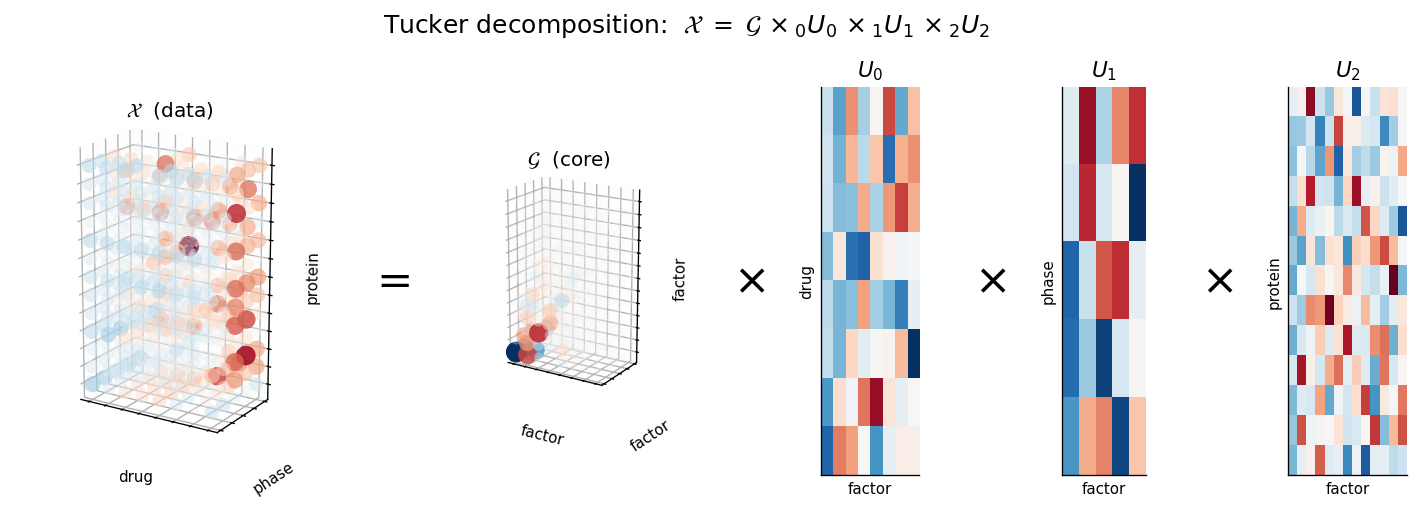

In [63]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 4.2))
gs = GridSpec(1, 9, width_ratios=[3.2, 0.6, 2.2, 0.7, 1.0, 0.7, 0.85, 0.7, 1.2], wspace=0.3)

def _glyph(col, s):
    a = fig.add_subplot(gs[0, col]); a.axis("off")
    a.text(0.5, 0.5, s, ha="center", va="center", fontsize=26)

def _factor_panel(col, U, name, rowname):
    a = fig.add_subplot(gs[0, col])
    vmax = np.abs(U).max() or 1.0
    a.imshow(U, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    a.set_title(name, fontsize=13)
    a.set_xlabel("factor", fontsize=9); a.set_ylabel(rowname, fontsize=9)
    a.set_xticks([]); a.set_yticks([])


ax0 = fig.add_subplot(gs[0, 0], projection="3d")

scatter3d(
    ax0, pseudobulk_tensor, axis_names=("drug", "phase", "protein"),
    title=r"$\mathcal{X}$  (data)", show_ticks=False, smax=140
)
_glyph(1, "=")
ax1 = fig.add_subplot(gs[0, 2], projection="3d")
scatter3d(
    ax1, core, axis_names=("factor", "factor", "factor"),
    title=r"$\mathcal{G}$  (core)", show_ticks=False, smax=140
)
_glyph(3, r"$\times$")
_factor_panel(4, factors[0], r"$U_0$", "drug")
_glyph(5, r"$\times$")
_factor_panel(6, factors[1], r"$U_1$", "phase")
_glyph(7, r"$\times$")
_factor_panel(8, factors[2], r"$U_2$", "protein")

fig.suptitle(
    r"Tucker decomposition:  $\mathcal{X} \;=\; \mathcal{G}\,\times_0 U_0\,\times_1 U_1\,\times_2 U_2$",
    fontsize=15, y=1.03
)
plt.show()

**2) Factor matrices $U_0$, $U_1$, $U_2$:**

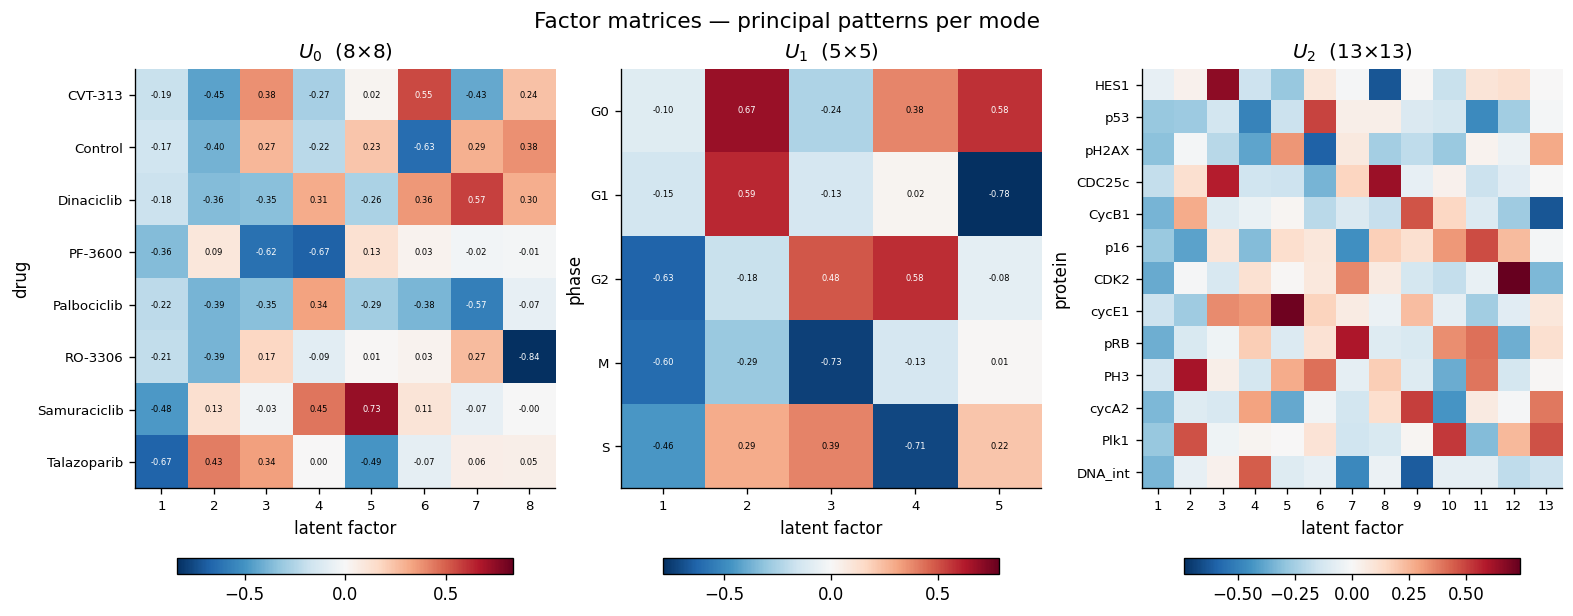

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True)

panels = [
    (factors[0], "U_0", "drug", drugs),
    (factors[1], "U_1", "phase", phases),
    (factors[2], "U_2", "protein", proteins)
]

for ax, (U, name, rowname, rowlabs) in zip(axes, panels):
    vmax = np.abs(U).max() or 1.0
    
    im = ax.imshow(U, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    
    ax.set_title(rf"${name}$  ({U.shape[0]}$\times${U.shape[1]})", fontsize=12)
    ax.set_xticks(np.arange(U.shape[1])); ax.set_xticklabels(np.arange(1, U.shape[1] + 1), fontsize=8)
    ax.set_xlabel("latent factor", fontsize=10)
    ax.set_yticks(np.arange(U.shape[0])); ax.set_yticklabels(rowlabs, fontsize=8)
    ax.set_ylabel(rowname, fontsize=10)
    
    if U.size <= 100:  # annotate small matrices
        for i in range(U.shape[0]):
            for j in range(U.shape[1]):
                ax.text(
                    j, i, f"{U[i, j]:.2f}", ha="center", va="center", fontsize=5,
                    color="white" if abs(U[i, j]) > 0.6 * vmax else "black"
                )
                
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, pad=0.04)

fig.suptitle("Factor matrices — principal patterns per mode", fontsize=13)
plt.show()

**3) Original tensor vs core, as 3-D voxel cubes:**

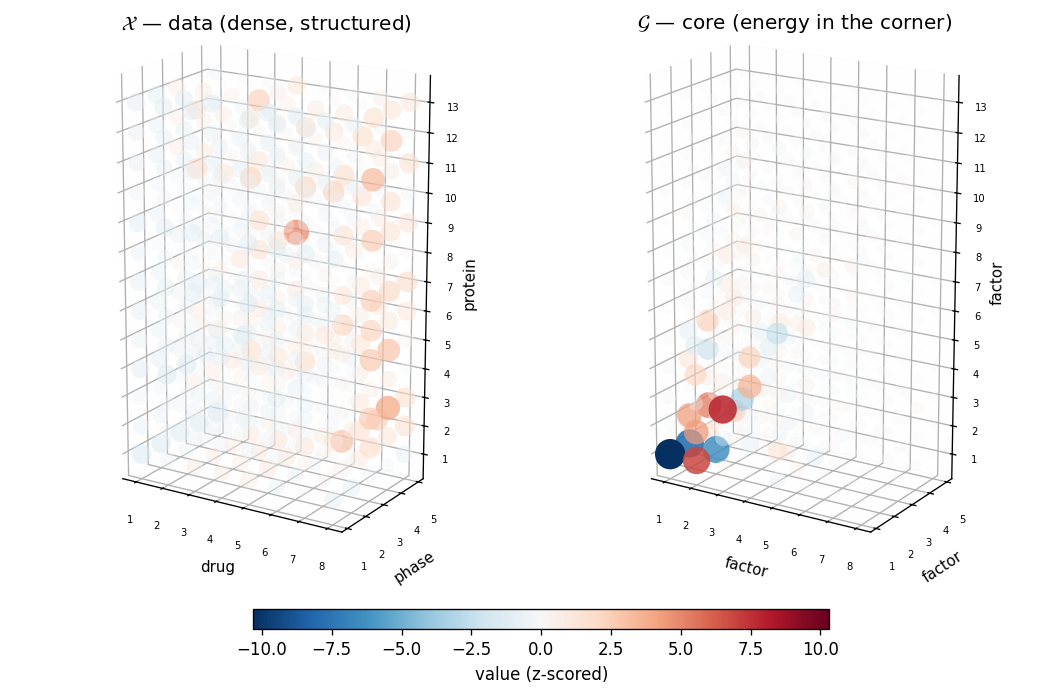

In [67]:
vmax = max(np.abs(pseudobulk_tensor).max(), np.abs(core).max())
fig = plt.figure(figsize=(12, 5.5))

ax0 = fig.add_subplot(1, 2, 1, projection="3d")
scatter3d(
    ax0, pseudobulk_tensor, vmax=vmax, axis_names=("drug", "phase", "protein"),
    title=r"$\mathcal{X}$ — data (dense, structured)"
)

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
sm = scatter3d(
    ax1, core, vmax=vmax, axis_names=("factor", "factor", "factor"),
    title=r"$\mathcal{G}$ — core (energy in the corner)"
)

cax = fig.add_axes([0.32, -0.02, 0.4, 0.03])
fig.colorbar(sm, cax=cax, orientation="horizontal", label="value (z-scored)")
  
fig.subplots_adjust(wspace=-0.1)
plt.show()

**4.1) Original tensor as slice montage:**

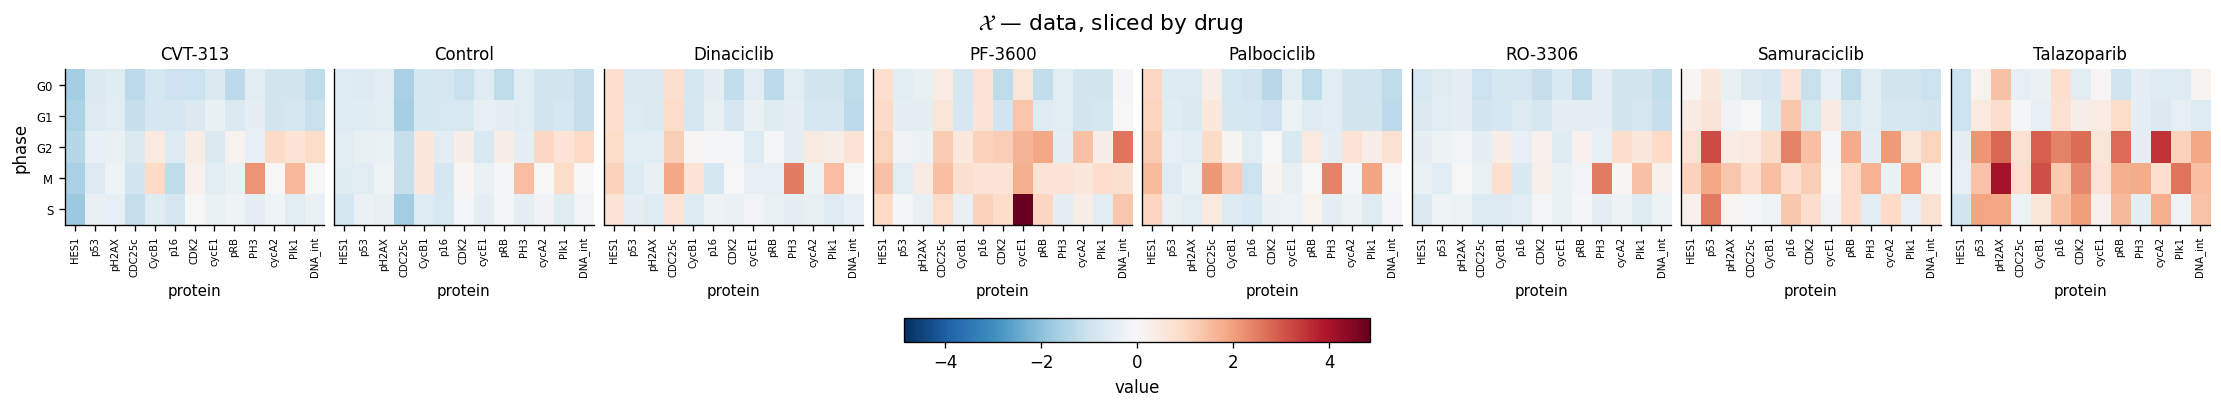

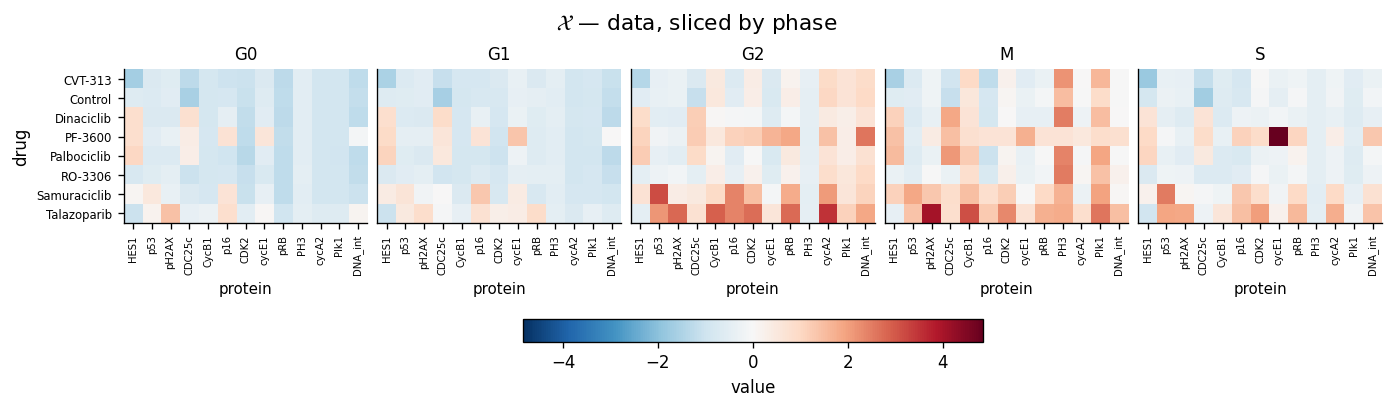

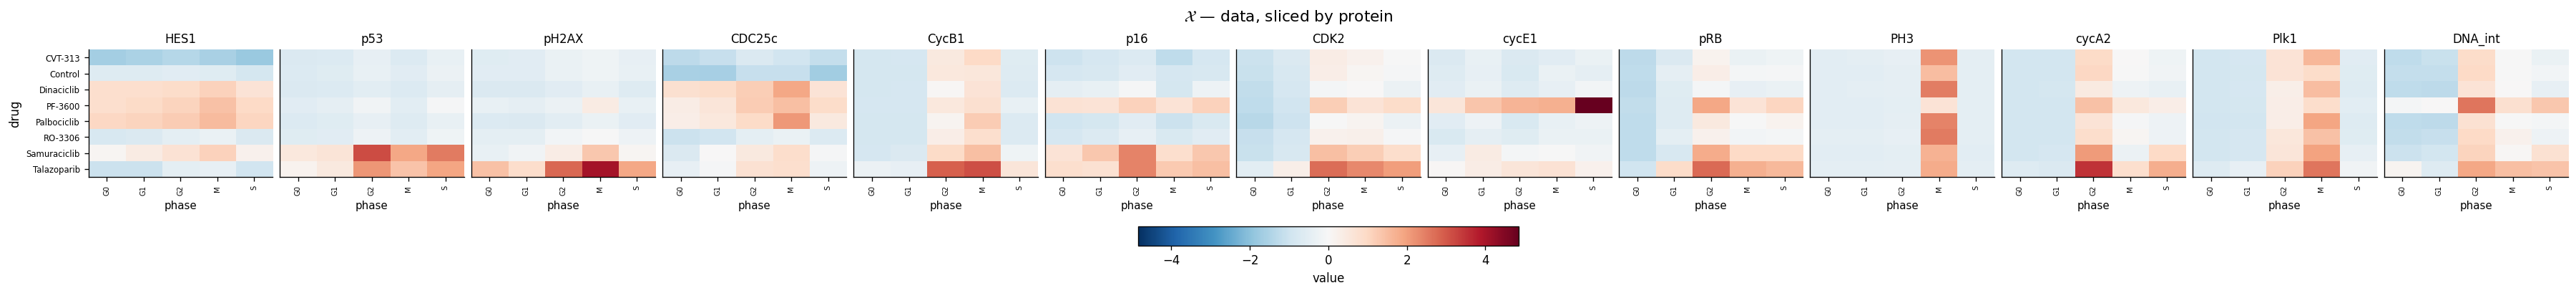

In [68]:
slice_montage(
    pseudobulk_tensor, axis=0,
    mode_names=("drug", "phase", "protein"),
    mode_ticklabels=(drugs, phases, proteins),
    title=r"$\mathcal{X}$ — data, sliced by drug"
)

slice_montage(
    pseudobulk_tensor, axis=1,
    mode_names=("drug", "phase", "protein"),
    mode_ticklabels=(drugs, phases, proteins),
    title=r"$\mathcal{X}$ — data, sliced by phase"
)

slice_montage(
    pseudobulk_tensor, axis=2,
    mode_names=("drug", "phase", "protein"),
    mode_ticklabels=(drugs, phases, proteins),
    title=r"$\mathcal{X}$ — data, sliced by protein"
)

plt.show()

**4.2) Core tensor as slice montage:**

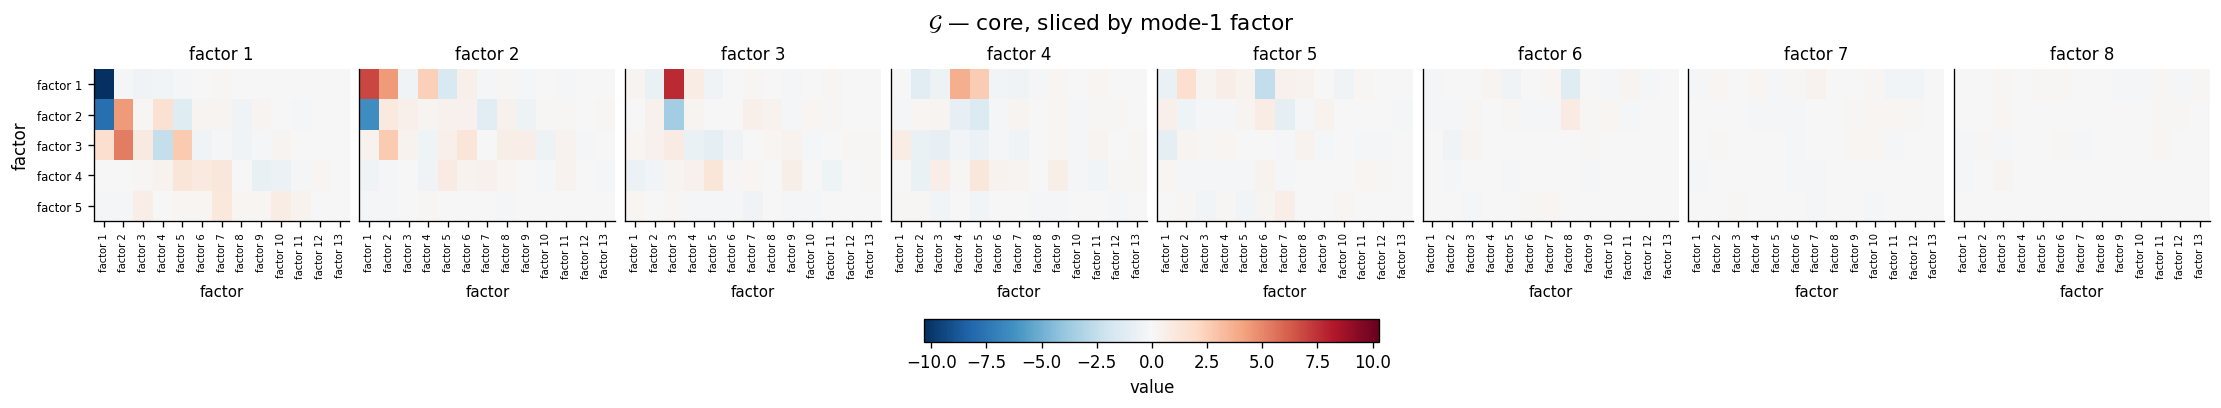

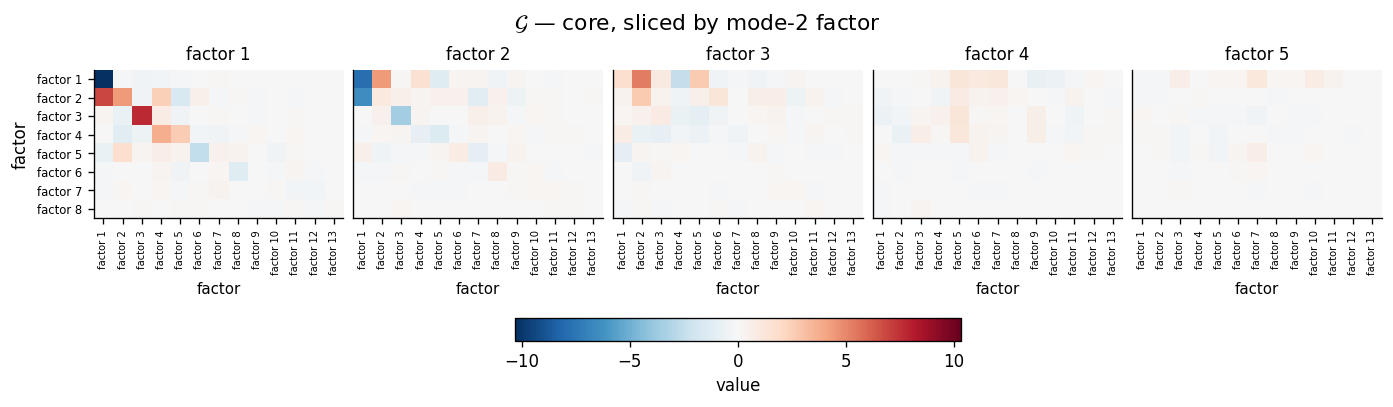

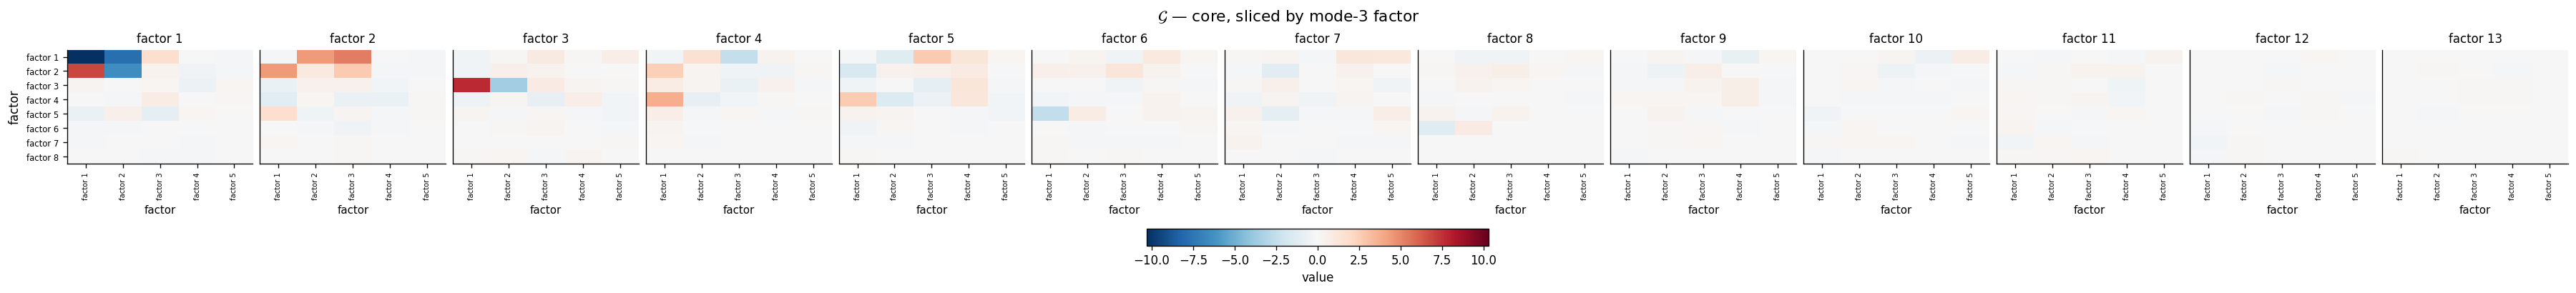

In [69]:
slice_montage(
    core, axis=0,
    mode_names=("factor", "factor", "factor"),
    mode_ticklabels=(None, None, None),
    title=r"$\mathcal{G}$ — core, sliced by mode-1 factor"
)

slice_montage(
    core, axis=1,
    mode_names=("factor", "factor", "factor"),
    mode_ticklabels=(None, None, None),
    title=r"$\mathcal{G}$ — core, sliced by mode-2 factor"
)

slice_montage(
    core, axis=2,
    mode_names=("factor", "factor", "factor"),
    mode_ticklabels=(None, None, None),
    title=r"$\mathcal{G}$ — core, sliced by mode-3 factor"
)

plt.show()

**5) The three single-mode products  $G \times_n U_n$,  as 3-D voxel cubes:**

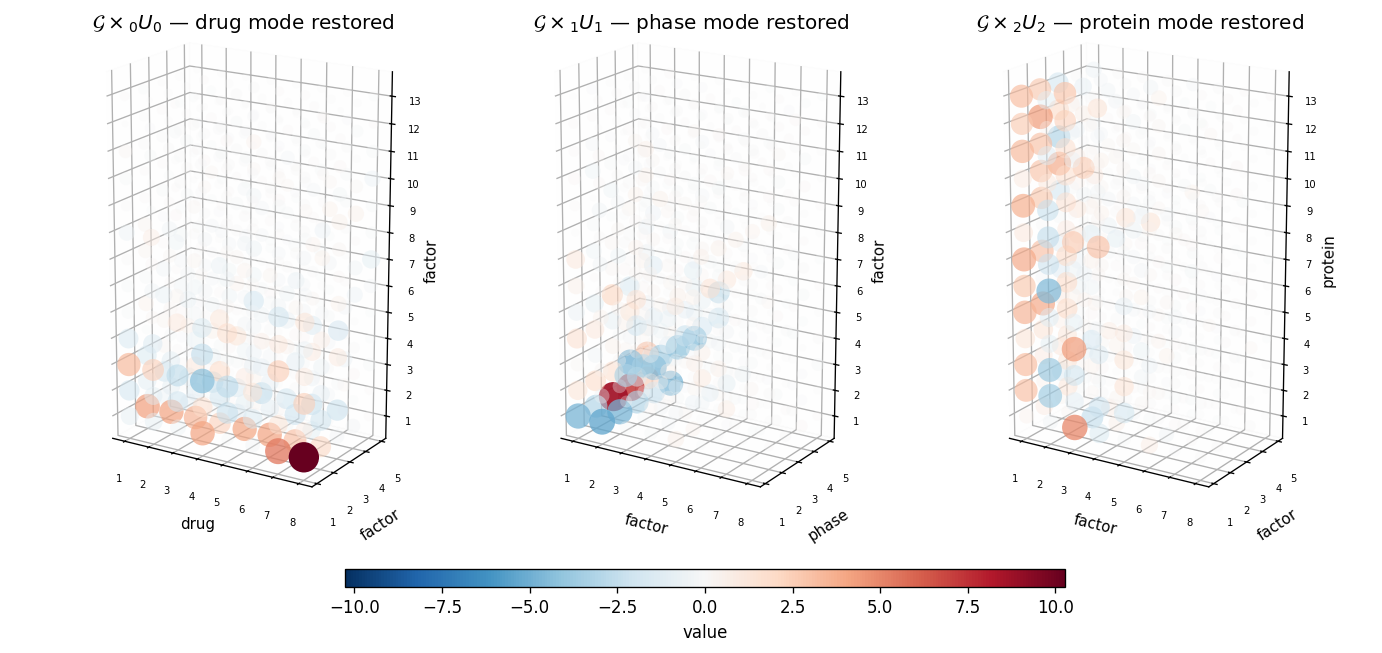

In [70]:
prods = [tenalg.mode_dot(core, factors[n], mode=n) for n in range(3)]
vmax = max(np.abs(p).max() for p in prods)

names = [("drug", "factor", "factor"), ("factor", "phase", "factor"), ("factor", "factor", "protein")]
titles = [
    r"$\mathcal{G}\times_0 U_0$ — drug mode restored",
    r"$\mathcal{G}\times_1 U_1$ — phase mode restored",
    r"$\mathcal{G}\times_2 U_2$ — protein mode restored"
]

fig = plt.figure(figsize=(15, 5))

for n in range(3):
    ax = fig.add_subplot(1, 3, n + 1, projection="3d")
    sm = scatter3d(ax, prods[n], vmax=vmax, axis_names=names[n], title=titles[n])

cax = fig.add_axes([0.32, -0.04, 0.4, 0.03])
fig.colorbar(sm, cax=cax, orientation="horizontal", label="value")
  
fig.subplots_adjust(wspace=-0.1)
plt.show()

**6) Three single-mode products  $G \times_n U_n$,  as slice montages:**

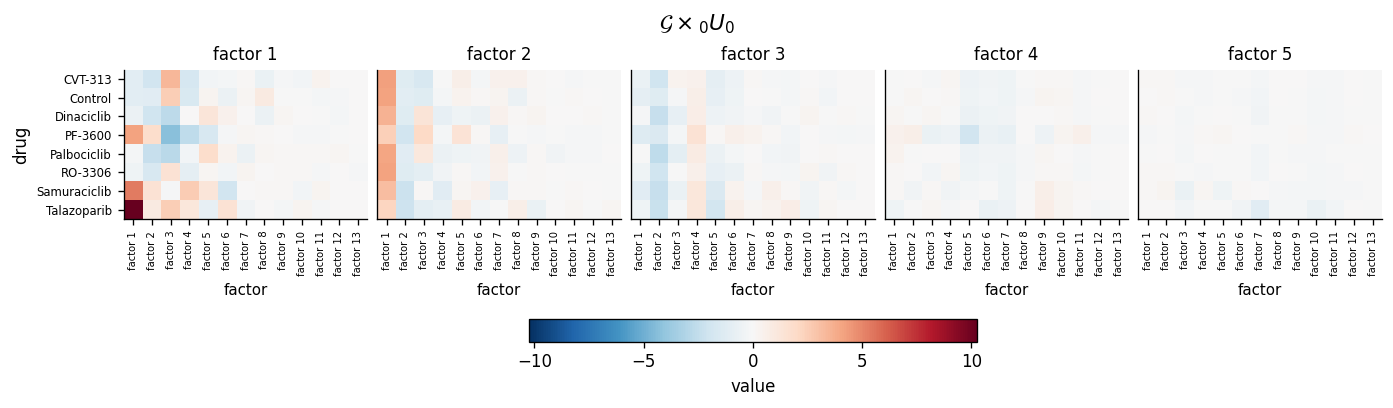

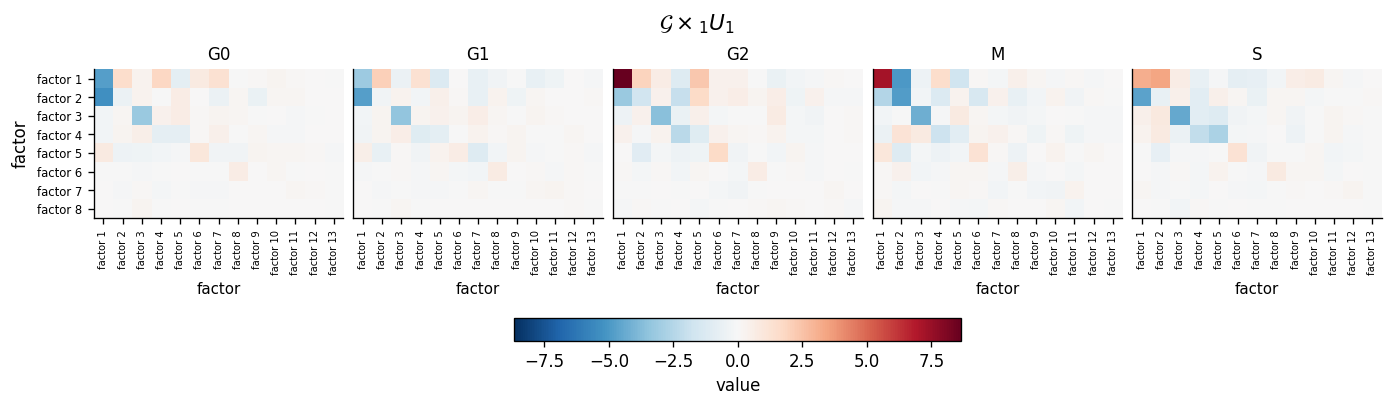

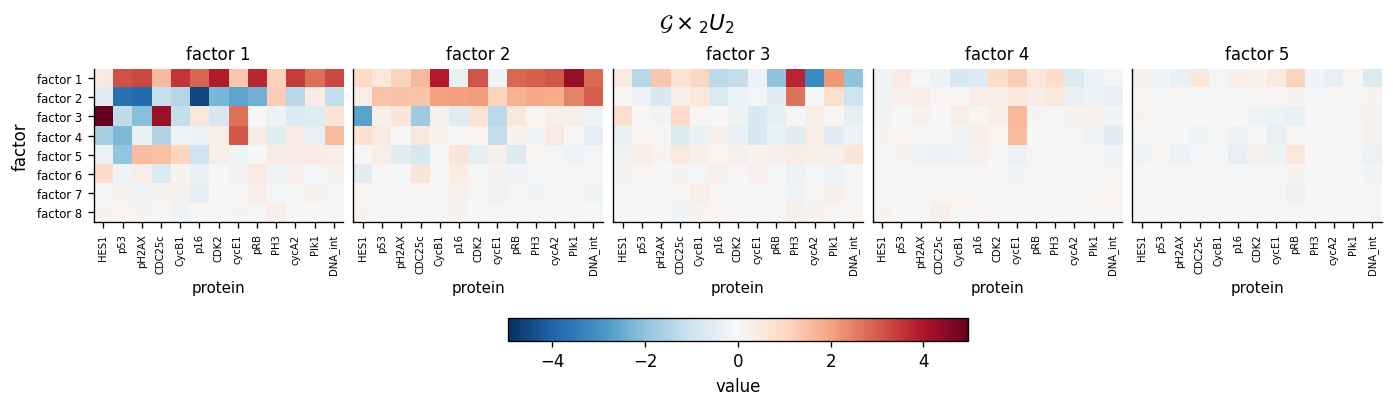

In [71]:
prods = [tenalg.mode_dot(core, factors[n], mode=n) for n in range(3)]

ticklabs = [(drugs, None, None), (None, phases, None), (None, None, proteins)]
names = [("drug", "factor", "factor"), ("factor", "phase", "factor"), ("factor", "factor", "protein")]
titles = [r"$\mathcal{G}\times_0 U_0$", r"$\mathcal{G}\times_1 U_1$", r"$\mathcal{G}\times_2 U_2$"]

for n in range(3):
    slice_montage(prods[n], axis=1, mode_names=names[n], mode_ticklabels=ticklabs[n], title=titles[n])

plt.show()

**7) Cumulative reconstruction:**

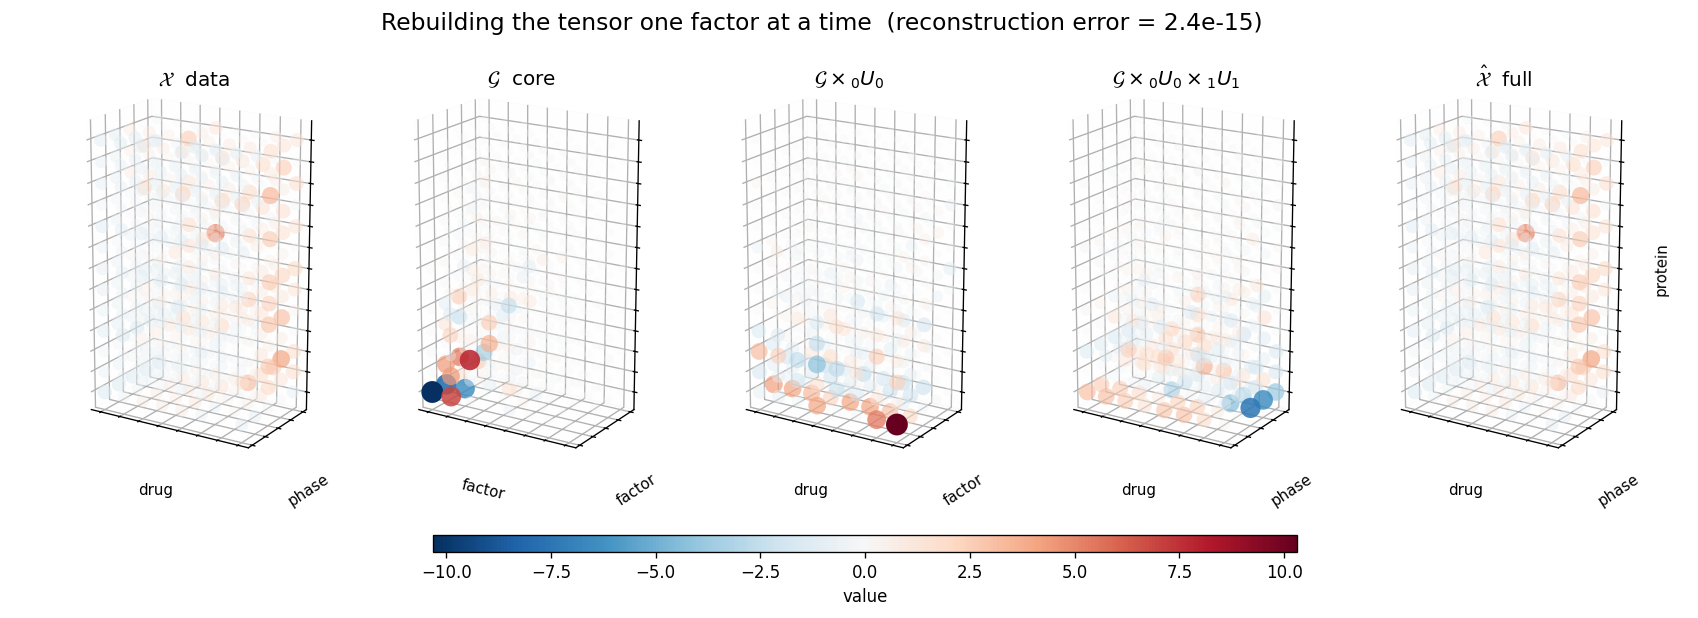

In [72]:
steps = [
    (pseudobulk_tensor, r"$\mathcal{X}$  data", ("drug", "phase", "protein")),
    (core, r"$\mathcal{G}$  core", ("factor", "factor", "factor")),
    (tenalg.mode_dot(core, factors[0], 0), r"$\mathcal{G}\times_0 U_0$", ("drug", "factor", "factor")),
    (tenalg.multi_mode_dot(core, [factors[0], factors[1]], modes=[0, 1]),
    r"$\mathcal{G}\times_0 U_0\times_1 U_1$", ("drug", "phase", "factor")),
    (tenalg.multi_mode_dot(core, factors), r"$\hat{\mathcal{X}}$  full", ("drug", "phase", "protein")),
]

recon = steps[-1][0]
err = np.linalg.norm(recon - pseudobulk_tensor) / np.linalg.norm(pseudobulk_tensor)
vmax = np.abs(core).max()

fig = plt.figure(figsize=(18, 4.5))

for i, (T, ttl, nm) in enumerate(steps):
    ax = fig.add_subplot(1, 5, i + 1, projection="3d")
    sm = scatter3d(ax, T, vmax=vmax, axis_names=nm, title=ttl, show_ticks=False, smax=160)

fig.suptitle(f"Rebuilding the tensor one factor at a time  (reconstruction error = {err:.1e})", fontsize=14)

cax = fig.add_axes([0.32, -0.02, 0.4, 0.03])
fig.colorbar(sm, cax=cax, orientation="horizontal", label="value")
  
fig.subplots_adjust(wspace=-0.1)
plt.show()

---